In [1]:
%cd ../../..

/home/filip/Desktop/PINN-for-Simulating-2D-Incompressible-Fluid-Dynamics


In [2]:
import pathlib

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
from torch import nn

from IPython.display import HTML, display
from pprint import pprint


import src.visuals as visual
import src.utils as utils

from src.models import PINN
from src.loss import NavierStokesLoss
from src.dataloader import load_data, gen_dataloaders
from src.train import train_model

In [3]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)


frac_size = 0.1

file_name = "data"
data_path = pathlib.Path(f"data/real_data/frac_{int(100*frac_size)}")

train_df, valid_df, test_df = load_data(data_path, file_name)

input_col_names = ['time', 're', 'x', 'y']
target_col_names = ['U_x', 'U_y', 'p']

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
train_df.describe()

,time,re,x,y,U_x,U_y,p
count,23639.000000,23639.000000,23639.000000,23639.000000,23639.000000,23639.000000,23639.000000
mean,4.985955,555.600180,0.501244,0.499518,-0.001158,-0.000030,-0.012095
std,3.158351,265.520813,0.288391,0.289040,0.163529,0.123972,0.040386
min,0.000000,100.000000,0.007812,0.007812,-0.326021,-0.626659,-0.443212
25%,2.000000,338.775510,0.257812,0.257812,-0.056371,-0.009741,-0.022463
50%,5.000000,577.551020,0.507812,0.492188,-0.015189,0.002476,-0.003470
75%,8.000000,779.591837,0.742188,0.757812,0.000000,0.056704,0.000054
max,10.000000,1000.000000,0.992188,0.992188,0.950837,0.271125,1.627520


In [5]:
valid_df.describe()

,time,re,x,y,U_x,U_y,p
count,4728.000000,4728.000000,4728.000000,4728.000000,4728.000000,4728.000000,4728.000000
mean,4.976523,574.276132,0.499544,0.508437,-0.000343,-0.001022,-0.012105
std,3.177840,262.593339,0.289592,0.288211,0.163843,0.127314,0.040869
min,0.000000,173.469388,0.007812,0.007812,-0.322576,-0.626091,-0.377887
25%,2.000000,302.040816,0.257812,0.257812,-0.054751,-0.009800,-0.022538
50%,5.000000,522.448980,0.507812,0.507812,-0.014301,0.002511,-0.003785
75%,8.000000,871.428571,0.757812,0.757812,0.000000,0.059524,0.000000
max,10.000000,926.530612,0.992188,0.992188,0.945098,0.272914,0.953805


In [6]:
test_df.describe()

,time,re,x,y,U_x,U_y,p
count,21630.000000,21630.000000,21630.000000,21630.000000,21630.000000,21630.000000,21630.000000
mean,4.981461,510.875768,0.502990,0.500403,0.000204,0.000027,-0.012765
std,3.174547,265.390242,0.286433,0.288654,0.170511,0.127538,0.041147
min,0.000000,118.367347,0.003906,0.003906,-0.344903,-0.648958,-1.096090
25%,2.000000,320.408163,0.261719,0.253906,-0.057867,-0.011625,-0.023693
50%,5.000000,559.183673,0.503906,0.503906,-0.015917,0.002106,-0.003417
75%,8.000000,853.061224,0.746094,0.746094,0.000000,0.058024,0.000045
max,10.000000,889.795918,0.996094,0.996094,0.974022,0.312527,1.166180


In [7]:
mean = train_df.mean()
std = train_df.std()

train_df = utils.normalize_data(train_df, mean, std)
valid_df = utils.normalize_data(valid_df, mean, std)
test_df = utils.normalize_data(test_df, mean, std)

In [8]:
train_dataloader, valid_dataloader, test_dataloader = gen_dataloaders(train_df, 
                                                                      valid_df, 
                                                                      test_df, 
                                                                      input_col_names, 
                                                                      target_col_names,
                                                                      1024)

In [9]:
model = PINN(len(input_col_names), len(target_col_names)).to(device)
criterion = NavierStokesLoss(0.5, mean, std)
optimizer = torch.optim.Adam(model.parameters())

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=15
)

EPOCHS = 200

In [10]:
n_param = sum([p.numel() for p in model.parameters()])

print("Number of parameters: ", n_param)

Number of parameters:  199427


In [11]:
run_dir = utils.create_run_directory(frac_size, label="cphys_0.5")

history = train_model(
    model,
    train_dataloader,
    valid_dataloader,
    criterion,
    optimizer,
    scheduler,
    device,
    EPOCHS,
    run_dir,
    checkpoint=None,
    physics_loss=True,
)

100%|██████████| 24/24 [00:00<00:00, 29.98it/s]


Epoch 0: train=0.762524 (data=0.760012, physics=0.005024) | valid=0.649192 (data=0.640406, physics=0.017570)


100%|██████████| 24/24 [00:00<00:00, 45.73it/s]


Epoch 1: train=0.516260 (data=0.505625, physics=0.021271) | valid=0.427880 (data=0.414082, physics=0.027596)


100%|██████████| 24/24 [00:00<00:00, 45.19it/s]


...

Epoch 197: train=0.006896 (data=0.004881, physics=0.004031) | valid=0.021560 (data=0.007672, physics=0.027774)


100%|██████████| 24/24 [00:00<00:00, 48.31it/s]


Epoch 198: train=0.006005 (data=0.004465, physics=0.003080) | valid=0.020860 (data=0.007419, physics=0.026882)


100%|██████████| 24/24 [00:00<00:00, 47.99it/s]


Epoch 199: train=0.005836 (data=0.004458, physics=0.002757) | valid=0.020851 (data=0.007396, physics=0.026910)


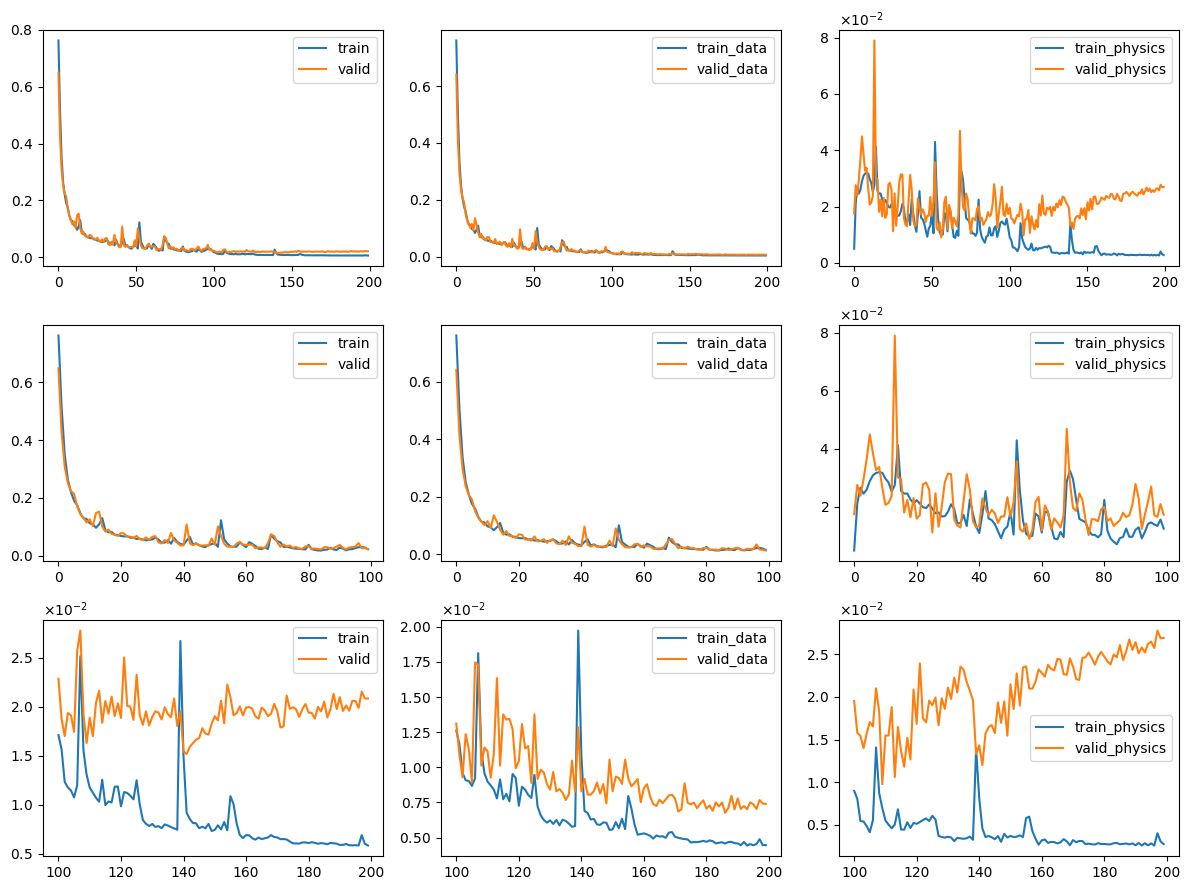

In [12]:
def plot(df, ax):
    for x in ax:
        x.ticklabel_format(axis='y', style='sci', scilimits=(-2,2), useMathText=True)

    df[["train", "valid"]].plot(ax=ax[0])
    df[["train_data", "valid_data"]].plot(ax=ax[1])
    df[["train_physics", "valid_physics"]].plot(ax=ax[2])
    
history_df = pd.DataFrame(history)

fig, ax = plt.subplots(3, 3, figsize=(12, 9), tight_layout=True)

plot(history_df, ax[0])
plot(history_df[:100], ax[1])
plot(history_df[100:], ax[2])

fig.savefig(run_dir / "losses.png")
history_df.to_csv(run_dir / "losess.csv")